# Phase 1 - Multilingual Graph Prototype
This notebook builds the semantic backbone of the graph engine, discovering all lexicon resources, supporting multiple languages.

Establish the foundational structure by creating language-independent concepts, their WordNet mappings, and domain classifications.

- concept_domain: Maps concepts to semantic domains and WordNet synsets
- Language lexicon files: english_ukc_lexicon (Nepali, Vietnamese, Urdu, Darija)




## Setup
Import necessary libraries and configure parameters.

## Discover input files
Detect which CSVs are available for semantic and abugida data.

In [50]:
input_dir = 'data'
resources = {
    'semantic': {
        'lexicons': {},
        'concept_domain': None,
        'synset_mapping': None
    },
    'abugida': {},
    'abjad': {},
    'alphabet': {},
}

def get_lang_code(filename):
    filename = filename.lower()
    if 'nepali' in filename or '_np' in filename: return 'np'
    if 'darija' in filename or '_dr' in filename: return 'dr'
    if 'urdu' in filename or '_ur' in filename: return 'ur'
    if 'vietnamese' in filename or 'viet' in filename or '_vn' in filename: return 'vn'
    return 'unknown'

for file in glob.glob(os.path.join(input_dir, '*.csv')) + glob.glob(os.path.join(input_dir, '*.tsv')):
    filename = os.path.basename(file)
    lower_name = filename.lower()
    if 'concept_domain' in lower_name:
        resources['semantic']['concept_domain'] = file
    elif 'ukc_wn30_mappings' in lower_name:
        resources['semantic']['synset_mapping'] = file
    elif 'abugida' in lower_name:
        lang = get_lang_code(lower_name)
        resources['abugida'][lang] = file
    elif 'abjad' in lower_name:
        lang = get_lang_code(lower_name)
        resources['abjad'][lang] = file
    elif 'alphabet' in lower_name:
        lang = get_lang_code(lower_name)
        resources['alphabet'][lang] = file
    elif 'lexicon' in lower_name:
        lang = get_lang_code(lower_name)
        resources['semantic']['lexicons'][lang] = file

print("Discovered Resources:", resources)

Discovered Resources: {'semantic': {'lexicons': {'np': 'data/nepali_english_ukc_lexicon_transliterated.csv', 'vn': 'data/vietnamese_english_ukc_lexicon.csv', 'ur': 'data/urdu_english_ukc_lexicon.csv', 'dr': 'data/darija_english_ukc_lexicon.csv'}, 'concept_domain': 'data/concept_domain.csv', 'synset_mapping': 'data/ukc_wn30_mappings (1).tsv'}, 'abugida': {'np': 'data/nepali_abugida_data.csv'}, 'abjad': {'dr': 'data/darija_abjad_data.csv'}, 'alphabet': {'ur': 'data/urdu_alphabet_data.csv', 'vn': 'data/vietnamese_alphabet_data (1).csv'}}


## Load and normalize 
Helper functions to keep everything clean and case-insensitive.

In [51]:
def normalize_columns(df):
    df.columns = [str(col).strip().lower() for col in df.columns]
    return df

def safe_text(value):
    if pd.isna(value):
        return ""
    return str(value).strip()

def make_node_id(node_type, *parts):
    clean_parts = [str(p).strip() for p in parts if str(p).strip()]
    return f"{node_type}:" + ":".join(clean_parts)

def add_node_if_missing(G, node_id, **attrs):
    if node_id and not G.has_node(node_id):
        G.add_node(node_id, **attrs)

def add_edge_if_missing(G, source, target, relation, **attrs):
    if source and target:
        if not G.has_edge(source, target):
            G.add_edge(source, target, relation=relation, **attrs)

## Build semantic graph (Pass 1)
Load the concepts from all sources, attaching domains and synsets.

Create a Concept node

- Gets the concept_id (like "ukc:0123")

- Creates a node with ID par example: "concept:ukc:0123"

> This is an abstract meaning independent of any language

Link to WordNet Synset (if exists)

- Gets the wn30_id (WordNet 3.0 identifier)

- Creates a synset node par example: "synset:0123-s"

- Adds an edge: concept --> synset with relation 'mapped_to_synset'

- This connects our concepts to the standard WordNet database

Link to Domain (if exists)

- Gets the domain (like "nature", "food", "sports")

- Creates a domain node "domain:nature"

- Adds an edge: concept --> domain with relation 'belongs_to_domain'

- This categorizes concepts by topic



In [52]:
#directed graph 
G = nx.DiGraph()

if resources['semantic']['concept_domain']:
    domain_df = pd.read_csv(resources['semantic']['concept_domain'])
    domain_df = normalize_columns(domain_df)
    for _, row in domain_df.iterrows():
        concept_id = safe_text(row.get('concept_id'))
        if not concept_id: continue
        c_node = make_node_id('concept', concept_id)
        add_node_if_missing(G, c_node, type='Concept', concept_id=concept_id)
        
        wn30_id = safe_text(row.get('wn30_id'))
        if wn30_id:
            s_node = make_node_id('synset', wn30_id)
            add_node_if_missing(G, s_node, type='Synset', wn30_id=wn30_id)
            add_edge_if_missing(G, c_node, s_node, relation='mapped_to_synset')
            
        domain = safe_text(row.get('domain'))
        if domain:
            d_node = make_node_id('domain', domain)
            add_node_if_missing(G, d_node, type='Domain', domain=domain)
            add_edge_if_missing(G, c_node, d_node, relation='belongs_to_domain')

for lang, filename in resources['semantic']['lexicons'].items():
    lex_df = pd.read_csv(filename)
    lex_df = normalize_columns(lex_df)
    for _, row in lex_df.iterrows():
        concept_id = safe_text(row.get('concept_id'))
        if not concept_id: continue
        c_node = make_node_id('concept', concept_id)
        add_node_if_missing(G, c_node, type='Concept', concept_id=concept_id)

print(f"Total nodes after pass 1: {G.number_of_nodes()}")

Total nodes after pass 1: 217333


## Build semantic graph (Pass 2)
Add lemmas (English, Target Language, and Romanized) and link them to concepts.

### we process english lemmas 

> Pass 2 takes the concept skeleton from Pass 1 and attaches multilingual words to it.

Node --> "lemma:eng:dog" with attributes (type='Lemma-eng', language='eng', text='dog')

Edge: lemma:eng:dog --> concept:ukc:123 with relation 'english_label_for'

In [53]:
for lang, filename in resources['semantic']['lexicons'].items():
    #Loops through each language's lexicon file (Nepali, Vietnamese, Urdu, and Darija).

    lex_df = pd.read_csv(filename)
    lex_df = normalize_columns(lex_df)
    for _, row in lex_df.iterrows():
        concept_id = safe_text(row.get('concept_id'))
        if not concept_id: continue
        c_node = make_node_id('concept', concept_id)
        
        eng_lemmas = safe_text(row.get('english_lemmas')).split('|')
        for lemma in eng_lemmas:
            lemma = lemma.strip()
            if lemma:
                e_node = make_node_id('lemma', 'eng', lemma)
                add_node_if_missing(G, e_node, type='Lemma-eng', language='eng', text=lemma)
                add_edge_if_missing(G, e_node, c_node, relation='english_label_for')
        
        lang_lemmas = [l.strip() for l in safe_text(row.get('lemmas')).split('|') if l.strip()] # native lang 
        roman_lemmas = [l.strip() for l in safe_text(row.get('transliterated form')).split('|') if l.strip()]  # fetch for transliterated form
        for i, lemma in enumerate(lang_lemmas):
            # Creates node: lemma:np:कुकुर with {type='Lemma-lang', language='np', text='कुकुर'}
            # Edge: lemma:np:कुकुर --> concept:ukc:12345 with relation 'target_label_for'
            l_node = make_node_id('lemma', lang, lemma)
            add_node_if_missing(G, l_node, type='Lemma-lang', language=lang, text=lemma) 
            add_edge_if_missing(G, l_node, c_node, relation='target_label_for')
                      
            if len(lang_lemmas) == len(roman_lemmas): #  we link lemma and its transliterated form
                r_lemma = roman_lemmas[i]
                if r_lemma:
                    r_node = make_node_id('roman', lang, r_lemma)
                    add_node_if_missing(G, r_node, type='Lemma-roman', language=lang, text=r_lemma)
                    add_edge_if_missing(G, l_node, r_node, relation='romanised_as')

print(f"Total nodes after pass 2: {G.number_of_nodes()}")
print(f"Total edges after pass 2: {G.number_of_edges()}")

Total nodes after pass 2: 289651
Total edges after pass 2: 306252


## Visualize graph checkpoints (Semantic Layer)
Visualizing the semantic layer with its edges.

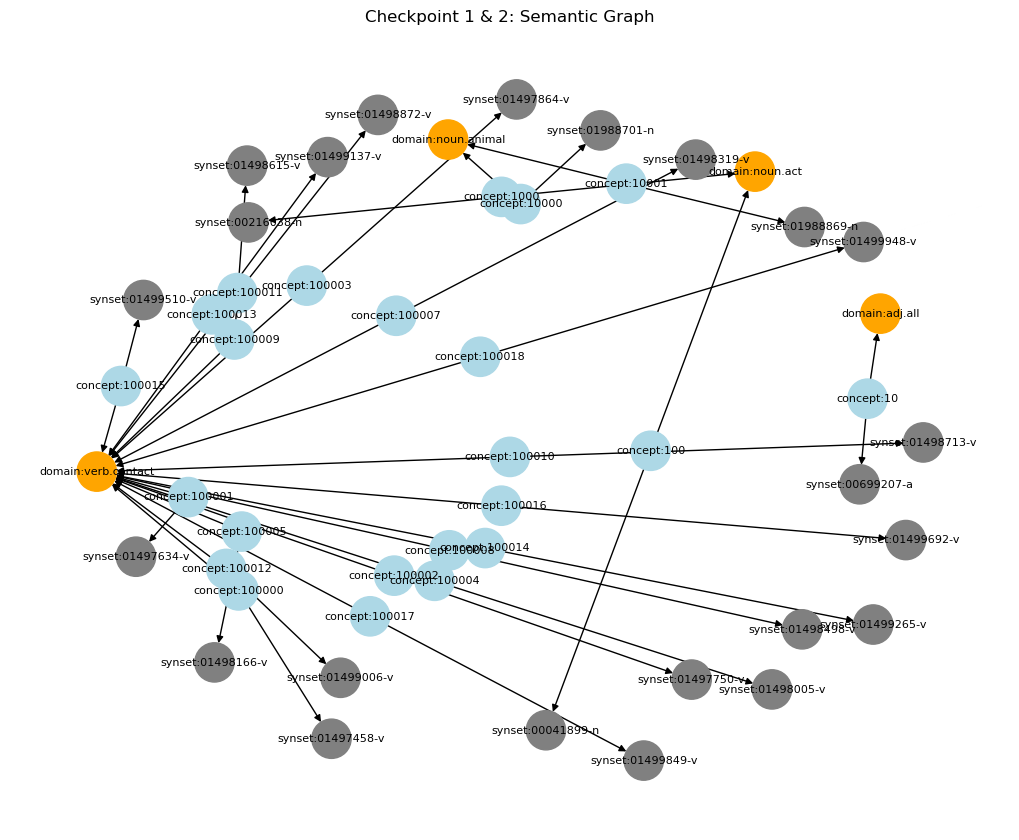

In [54]:
def visualize_sample(G, title, sample_size=50):
    if G.number_of_nodes() == 0:
        print("Graph is empty.")
        return
    sub_nodes = list(G.nodes())[:sample_size] #sample size 50 
    subG = G.subgraph(sub_nodes)
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(subG, seed=12)
    color_map = []
    for node in subG.nodes():
        t = subG.nodes[node].get('type', '')
        if t == 'Concept': color_map.append('lightblue')
        elif t == 'Lemma-eng': color_map.append('lightgreen')
        elif t == 'Lemma-lang': color_map.append('lightcoral')
        elif t == 'Domain': color_map.append('orange')
        else: color_map.append('gray') # these are synsets, romanizations
    nx.draw(subG, pos, with_labels=True, node_color=color_map, node_size=800, font_size=8)
    plt.title(title)
    plt.show()

visualize_sample(G, "Checkpoint 1 & 2: Semantic Graph", sample_size=50)

Sampled nodes by type:
  Concepts: 10
  English lemmas: 10
  Target language lemmas: 10
  Romanized lemmas: 10
  Domains: 5
  Synsets: 15
  Total nodes in visualization: 60
  Total edges in visualization: 30


/var/folders/2h/by_936gd5jscnq_cnry46n240000gn/T/ipykernel_60642/4087332584.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2326 (\N{DEVANAGARI LETTER KHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2339 (\N{DEVANAGARI LETTER NNA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_fig

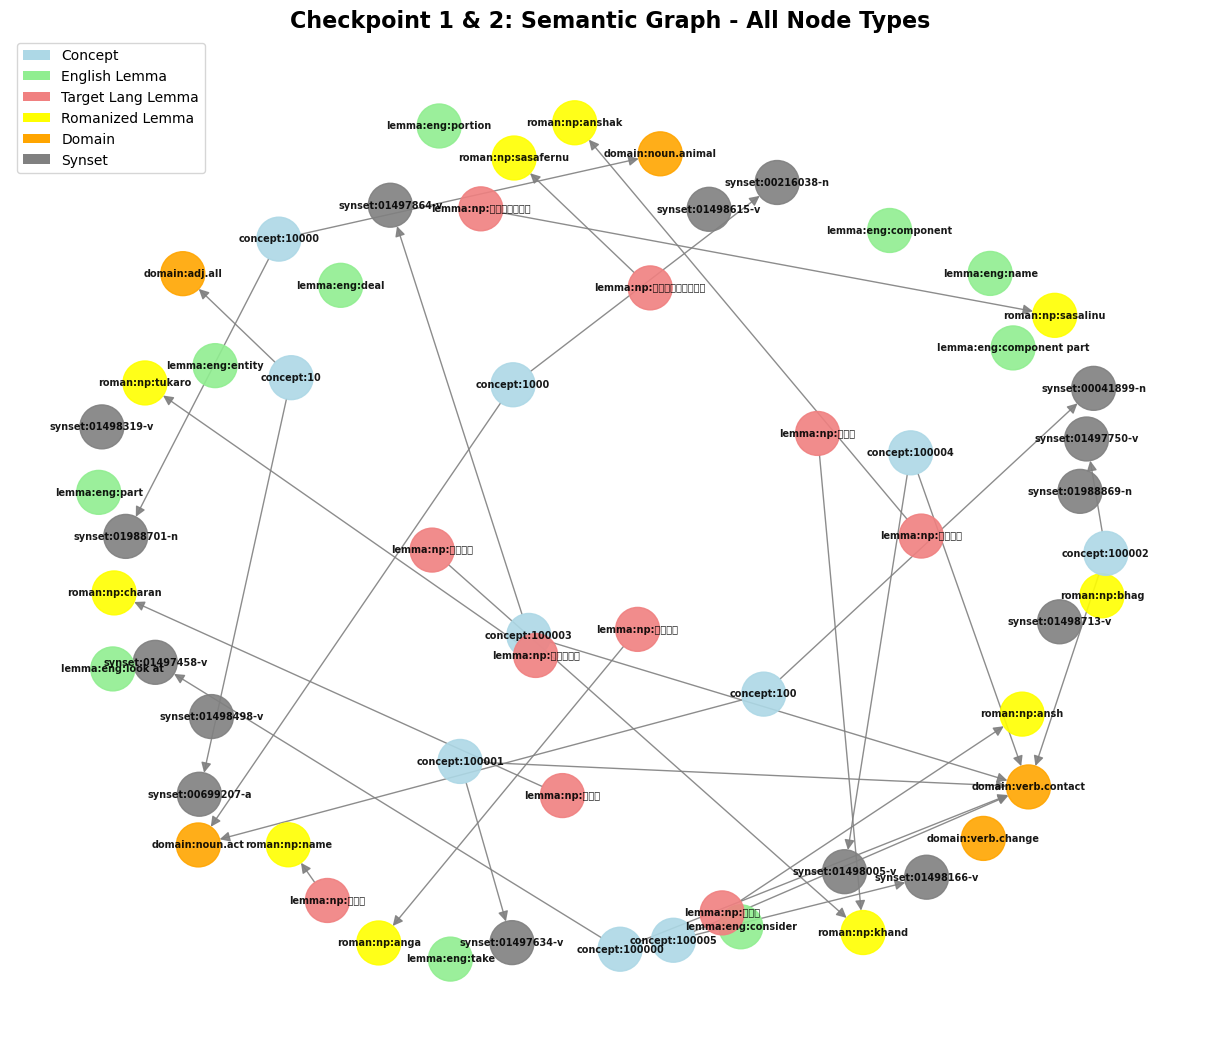

In [55]:
def visualize_sample_mixed(G, title, sample_size=50):
    """
    Visualize a mixed sample of different node types from the graph.
    Ensures representation of all node types for better understanding.
    
    Args:
        G: NetworkX graph
        title: Title for the plot
        sample_size: Total number of nodes to sample (distributed across types)
    """
    if G.number_of_nodes() == 0:
        print("Graph is empty.")
        return
    
    # Sample different node types proportionally ... randomly takes first # sets and just stops 
    concepts = [n for n, d in G.nodes(data=True) if d.get('type') == 'Concept'][:10]
    eng_lemmas = [n for n, d in G.nodes(data=True) if d.get('type') == 'Lemma-eng'][:10]
    lang_lemmas = [n for n, d in G.nodes(data=True) if d.get('type') == 'Lemma-lang'][:10]
    roman_lemmas = [n for n, d in G.nodes(data=True) if d.get('type') == 'Lemma-roman'][:10]
    domains = [n for n, d in G.nodes(data=True) if d.get('type') == 'Domain'][:5]
    synsets = [n for n, d in G.nodes(data=True) if d.get('type') == 'Synset'][:15]
    
    # Combine all sampled nodes
    sub_nodes = concepts + eng_lemmas + lang_lemmas + roman_lemmas + domains + synsets
    
    # Create subgraph with all edges between these nodes
    subG = G.subgraph(sub_nodes)
    
    print(f"Sampled nodes by type:")
    print(f"  Concepts: {len(concepts)}")
    print(f"  English lemmas: {len(eng_lemmas)}")
    print(f"  Target language lemmas: {len(lang_lemmas)}")
    print(f"  Romanized lemmas: {len(roman_lemmas)}")
    print(f"  Domains: {len(domains)}")
    print(f"  Synsets: {len(synsets)}")
    print(f"  Total nodes in visualization: {len(sub_nodes)}")
    print(f"  Total edges in visualization: {subG.number_of_edges()}")
    
    # Set up the plot
    plt.figure(figsize=(12, 10))
    
    # Use spring layout for organic positioning
    pos = nx.spring_layout(subG, seed=42, k=0.8, iterations=50)
    
    # Color mapping for different node types
    color_map = []
    for node in subG.nodes():
        t = subG.nodes[node].get('type', '')
        if t == 'Concept': 
            color_map.append('lightblue')
        elif t == 'Lemma-eng': 
            color_map.append('lightgreen')
        elif t == 'Lemma-lang': 
            color_map.append('lightcoral')
        elif t == 'Lemma-roman': 
            color_map.append('yellow')
        elif t == 'Domain': 
            color_map.append('orange')
        elif t == 'Synset': 
            color_map.append('gray')
        else: 
            color_map.append('pink')
    
    # Draw the graph
    nx.draw(subG, pos, 
            with_labels=True, 
            node_color=color_map, 
            node_size=1000, 
            font_size=7,
            font_weight='bold',
            edge_color='gray',
            alpha=0.9,
            arrowsize=15)
    
    plt.title(title, fontsize=16, fontweight='bold')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='lightblue', label='Concept'),
        Patch(facecolor='lightgreen', label='English Lemma'),
        Patch(facecolor='lightcoral', label='Target Lang Lemma'),
        Patch(facecolor='yellow', label='Romanized Lemma'),
        Patch(facecolor='orange', label='Domain'),
        Patch(facecolor='gray', label='Synset')
    ]
    plt.legend(handles=legend_elements, loc='upper left', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Call the function
visualize_sample_mixed(G, "Checkpoint 1 & 2: Semantic Graph - All Node Types")
       

## Attach optional abugida layers
Connect the phoneme/grapheme data when it exists. We maintain a distinct `Lemma-roman-abugida` for transliteration.

### This can be considered as pass 3, but this is isolated and doesn't connect to the pass 1 or pass 2 nodes

In [56]:
def attach_abugida_layer(G, lang, csv_path):
    if not os.path.exists(csv_path):
        print(f"Skipping: {csv_path} not found.")
        return
    df = pd.read_csv(csv_path)
    df = normalize_columns(df)
    nodes_added = 0
    edges_added = 0
    for _, row in df.iterrows():
        char = safe_text(row.get('character'))
        if not char: continue
        # Grapheme node: grapheme:np:क 
        #Stores in this way -->  {type='Grapheme', language='np', char='क'}
        g_node = make_node_id('grapheme', lang, char)
        add_node_if_missing(G, g_node, type='Grapheme', language=lang, char=char)
        nodes_added += 1
        
        ipa = safe_text(row.get('ipa'))
        p_node = None
        # create phoneme node and link like: phonmene:np:/ka/ --> written as --> grapheme:np: क
        if ipa:
            p_node = make_node_id('phoneme', lang, ipa)
            add_node_if_missing(G, p_node, type='Phoneme', language=lang, ipa=ipa)
            add_edge_if_missing(G, p_node, g_node, relation='phoneme_written_as')
            nodes_added += 1
            edges_added += 1

        # adds transliteration node and links as such    
        trans = safe_text(row.get('transliteration'))
        if trans and p_node:
            r_node = make_node_id('abugida_roman', lang, trans)
            add_node_if_missing(G, r_node, type='Lemma-roman-abugida', language=lang, text=trans)
            add_edge_if_missing(G, p_node, r_node, relation='phoneme_transliterated_as')
            nodes_added += 1
            edges_added += 1
            
        audio = safe_text(row.get('audio')) or safe_text(row.get('audio_path'))
        if audio and p_node:
            a_node = make_node_id('audio', lang, audio)
            add_node_if_missing(G, a_node, type='Audio', language=lang, audio_path=audio)
            add_edge_if_missing(G, a_node, p_node, relation='audio_represents')
            nodes_added += 1
            edges_added += 1
            
    print(f"Attached abugida layer {lang}: ~{nodes_added} nodes, {edges_added} edges.")

for lang, filepath in resources['abugida'].items():
    attach_abugida_layer(G, lang, filepath)

Attached abugida layer np: ~212 nodes, 159 edges.


## Visualize graph checkpoints (Abugida)
Visualizing the abugida subgraph.

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2309 (\N{DEVANAGARI LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2307 (\N{DEVANAGARI SIGN VISARGA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2314 (\N{DEVANAGARI LETTER UU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2315 (\N{DEVANAGARI LETTER VOCALIC R}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes

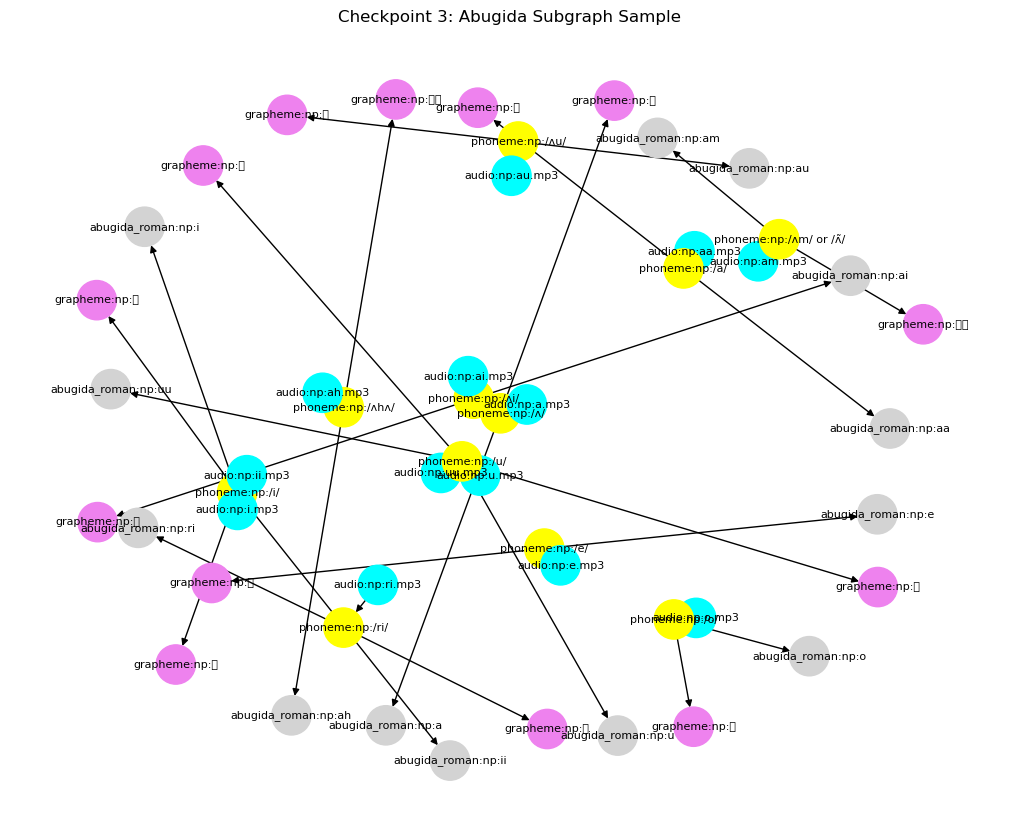

In [57]:
abugida_nodes = [n for n in G.nodes() if G.nodes[n].get('type') in ['Grapheme', 'Phoneme', 'Audio', 'Lemma-roman-abugida']]
if abugida_nodes:
    subG_abugida = G.subgraph(abugida_nodes[:50])
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(subG_abugida, seed=42)
    color_map = []
    for node in subG_abugida.nodes():
        t = subG_abugida.nodes[node].get('type', '')
        if t == 'Grapheme': color_map.append('violet')
        elif t == 'Phoneme': color_map.append('yellow')
        elif t == 'Audio': color_map.append('cyan')
        else: color_map.append('lightgray')
    nx.draw(subG_abugida, pos, with_labels=True, node_color=color_map, node_size=800, font_size=8)
    plt.title("Checkpoint 3: Abugida Subgraph Sample")
    plt.show()
else:
    print("No abugida nodes available to visualize.")

In [58]:
def attach_vietnamese_alphabet(G, lang, csv_path):
    """
    Attach Vietnamese alphabet data to the knowledge graph. phase 3 continues 
    Vietnamese uses Latin script with diacritics.
    """
    if not os.path.exists(csv_path):
        print(f"Skipping: {csv_path} not found.")
        return
    
    df = pd.read_csv(csv_path)
    df = normalize_columns(df)
    
    nodes_added = 0
    edges_added = 0
    
    for _, row in df.iterrows():
        # Get character (primary form)
        char = safe_text(row.get('character'))
        if not char:
            continue
        
        # Get character type (Vowel/Consonant)
        char_type = safe_text(row.get('type'))
        
        # Create GRAPHEME node for the character
        g_node = make_node_id('grapheme', lang, char)
        add_node_if_missing(G, g_node, 
                          type='Grapheme', 
                          language=lang, 
                          char=char,
                          char_type=char_type)
        nodes_added += 1
        
        # Handle uppercase variant (additional form)
        upper_char = safe_text(row.get('additional_form'))
        if upper_char:
            upper_node = make_node_id('grapheme', lang, upper_char)
            add_node_if_missing(G, upper_node,
                              type='Grapheme',
                              language=lang,
                              char=upper_char,
                              char_type=char_type,
                              case='uppercase')
            # Link uppercase to lowercase as variant
            add_edge_if_missing(G, upper_node, g_node, 
                              relation='uppercase_of')
            nodes_added += 1
            edges_added += 1
        
        # Create PHONEME node (IPA)
        ipa = safe_text(row.get('ipa'))
        p_node = None
        if ipa:
            p_node = make_node_id('phoneme', lang, ipa)
            add_node_if_missing(G, p_node, 
                              type='Phoneme', 
                              language=lang, 
                              ipa=ipa)
            # Link phoneme to grapheme
            add_edge_if_missing(G, p_node, g_node, 
                              relation='phoneme_written_as')
            nodes_added += 1
            edges_added += 1
        
        # Create TRANSLITERATION node (simplified romanization)
        trans = safe_text(row.get('transliteration'))
        if trans and p_node:
            # Use different node type to distinguish from abugida romanization
            r_node = make_node_id('latin_roman', lang, trans)
            add_node_if_missing(G, r_node, 
                              type='Lemma-roman-latin', 
                              language=lang, 
                              text=trans)
            # Link phoneme to transliteration
            add_edge_if_missing(G, p_node, r_node, 
                              relation='phoneme_transliterated_as')
            nodes_added += 1
            edges_added += 1
        
        # Create AUDIO node
        audio = safe_text(row.get('audio'))
        if audio and p_node:
            a_node = make_node_id('audio', lang, audio)
            add_node_if_missing(G, a_node, 
                              type='Audio', 
                              language=lang, 
                              audio_path=audio)
            # Link audio to phoneme
            add_edge_if_missing(G, a_node, p_node, 
                              relation='audio_represents')
            nodes_added += 1
            edges_added += 1
    
    print(f"Attached Vietnamese alphabet layer for {lang}: ~{nodes_added} nodes, {edges_added} edges.")
    
    # Print summary statistics
    vowel_count = len([n for n, d in G.nodes(data=True) 
                      if d.get('language') == lang 
                      and d.get('char_type') == 'Vowel'])
    consonant_count = len([n for n, d in G.nodes(data=True) 
                          if d.get('language') == lang 
                          and d.get('char_type') == 'Consonant'])
    
    print(f"  Vowels: {vowel_count}")
    print(f"  Consonants: {consonant_count}")


for lang, filepath in resources['alphabet'].items():
    if lang == 'vn':
        attach_vietnamese_alphabet(G, lang, filepath)

Attached Vietnamese alphabet layer for vn: ~445 nodes, 356 edges.
  Vowels: 24
  Consonants: 34


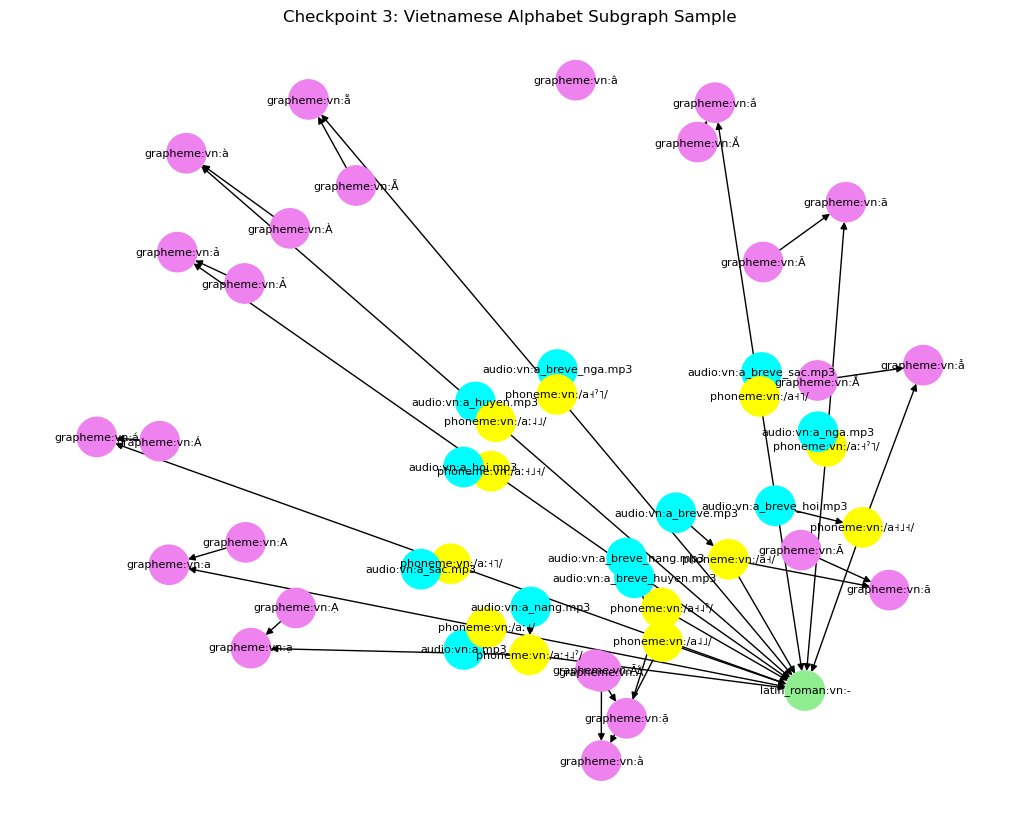

In [59]:
# Visualize Vietnamese alphabet layer
alphabet_nodes = [n for n in G.nodes() if G.nodes[n].get('type') in ['Grapheme', 'Phoneme', 'Audio', 'Lemma-roman-latin'] and G.nodes[n].get('language') == 'vn']
if alphabet_nodes:
    subG_alphabet = G.subgraph(alphabet_nodes[:50])
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(subG_alphabet, seed=42)
    color_map = []
    for node in subG_alphabet.nodes():
        t = subG_alphabet.nodes[node].get('type', '')
        if t == 'Grapheme': 
            color_map.append('violet')
        elif t == 'Phoneme': 
            color_map.append('yellow')
        elif t == 'Audio': 
            color_map.append('cyan')
        elif t == 'Lemma-roman-latin':
            color_map.append('lightgreen')
        else: 
            color_map.append('lightgray')
    
    nx.draw(subG_alphabet, pos, with_labels=True, node_color=color_map, node_size=800, font_size=8)
    plt.title("Checkpoint 3: Vietnamese Alphabet Subgraph Sample")
    plt.show()
else:
    print("No Vietnamese alphabet nodes available to visualize.")

In [60]:
def attach_urdu_alphabet(G, lang, csv_path):
    """
    Attach Urdu alphabet data to the knowledge graph.
    Urdu uses the Arabic script.
    """
    import pandas as pd
    import os
    if not os.path.exists(csv_path):
        print(f"Skipping: {csv_path} not found.")
        return
    
    df = pd.read_csv(csv_path)
    df = normalize_columns(df)
    
    nodes_added = 0
    edges_added = 0
    
    for _, row in df.iterrows():
        # Get character (primary form)
        char = safe_text(row.get('character'))
        if not char:
            continue
        
        # Get character type (Vowel/Consonant)
        char_type = safe_text(row.get('type'))
        
        # Create GRAPHEME node for the character
        g_node = make_node_id('grapheme', lang, char)
        add_node_if_missing(G, g_node, 
                          type='Grapheme', 
                          language=lang, 
                          char=char,
                          char_type=char_type)
        nodes_added += 1
        
        # Handle uppercase variant (additional form)
        upper_char = safe_text(row.get('additional_form'))
        if upper_char and upper_char != '-':
            upper_node = make_node_id('grapheme', lang, upper_char)
            add_node_if_missing(G, upper_node,
                              type='Grapheme',
                              language=lang,
                              char=upper_char,
                              char_type=char_type,
                              case='uppercase')
            # Link uppercase to lowercase as variant
            add_edge_if_missing(G, upper_node, g_node, 
                              relation='uppercase_of')
            nodes_added += 1
            edges_added += 1
        
        # Create PHONEME node (IPA)
        ipa = safe_text(row.get('ipa'))
        p_node = None
        if ipa and ipa != '-':
            p_node = make_node_id('phoneme', lang, ipa)
            add_node_if_missing(G, p_node, 
                              type='Phoneme', 
                              language=lang, 
                              ipa=ipa)
            # Link phoneme to grapheme
            add_edge_if_missing(G, p_node, g_node, 
                              relation='phoneme_written_as')
            nodes_added += 1
            edges_added += 1
        
        # Create TRANSLITERATION node (simplified romanization)
        trans = safe_text(row.get('transliteration'))
        if trans and trans != '-' and p_node:
            # Use different node type to distinguish from abugida romanization
            r_node = make_node_id('latin_roman', lang, trans)
            add_node_if_missing(G, r_node, 
                              type='Lemma-roman-latin', 
                              language=lang, 
                              text=trans)
            # Link phoneme to transliteration
            add_edge_if_missing(G, p_node, r_node, 
                              relation='phoneme_transliterated_as')
            nodes_added += 1
            edges_added += 1
        
        # Create AUDIO node
        audio = safe_text(row.get('audio'))
        if audio and audio != '-' and p_node:
            a_node = make_node_id('audio', lang, audio)
            add_node_if_missing(G, a_node, 
                              type='Audio', 
                              language=lang, 
                              audio_path=audio)
            # Link audio to phoneme
            add_edge_if_missing(G, a_node, p_node, 
                              relation='audio_represents')
            nodes_added += 1
            edges_added += 1
    
    print(f"Attached Urdu alphabet layer for {lang}: ~{nodes_added} nodes, {edges_added} edges.")
    
    # Print summary statistics
    vowel_count = len([n for n, d in G.nodes(data=True) 
                      if d.get('language') == lang 
                      and d.get('char_type') == 'Vowel'])
    consonant_count = len([n for n, d in G.nodes(data=True) 
                          if d.get('language') == lang 
                          and d.get('char_type') == 'Consonant'])
    
    print(f"  Vowels: {vowel_count}")
    print(f"  Consonants: {consonant_count}")

if 'ur' in resources['alphabet']:
    attach_urdu_alphabet(G, 'ur', resources['alphabet']['ur'])

Attached Urdu alphabet layer for ur: ~156 nodes, 117 edges.
  Vowels: 4
  Consonants: 35


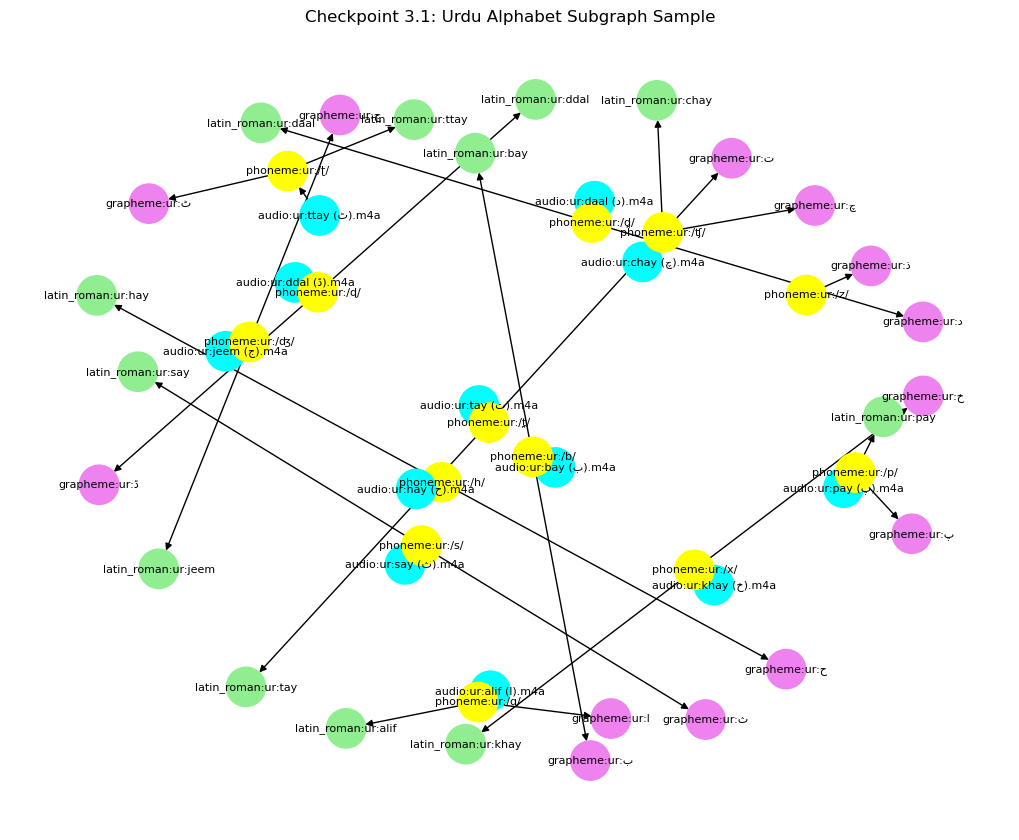

In [61]:
# Visualize Urdu alphabet layer
alphabet_nodes_ur = [n for n in G.nodes() if G.nodes[n].get('type') in ['Grapheme', 'Phoneme', 'Audio', 'Lemma-roman-latin'] and G.nodes[n].get('language') == 'ur']
if alphabet_nodes_ur:
    subG_alphabet_ur = G.subgraph(alphabet_nodes_ur[:50])
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(subG_alphabet_ur, seed=42)
    color_map = []
    for node in subG_alphabet_ur.nodes():
        t = subG_alphabet_ur.nodes[node].get('type', '')
        if t == 'Grapheme': 
            color_map.append('violet')
        elif t == 'Phoneme': 
            color_map.append('yellow')
        elif t == 'Audio': 
            color_map.append('cyan')
        elif t == 'Lemma-roman-latin':
            color_map.append('lightgreen')
        else: 
            color_map.append('lightgray')
    
    nx.draw(subG_alphabet_ur, pos, with_labels=True, node_color=color_map, node_size=800, font_size=8)
    plt.title("Checkpoint 3.1: Urdu Alphabet Subgraph Sample")
    plt.show()
else:
    print("No Urdu alphabet nodes available to visualize.")

In [62]:
def attach_darija_abjad(G, lang, csv_path):
    """
    Attach Darija abjad data to the knowledge graph.
    Darija uses the Arabic script.
    """
    import os
    import pandas as pd
    
    if not os.path.exists(csv_path):
        print(f"Skipping: {csv_path} not found.")
        return
    
    df = pd.read_csv(csv_path)
    df = normalize_columns(df)
    
    nodes_added = 0
    edges_added = 0
    
    for _, row in df.iterrows():
        # Get character (primary form)
        char = safe_text(row.get('character'))
        if not char:
            continue
        
        # Get character type (Long_Vowel/Consonant)
        char_type = safe_text(row.get('type'))
        
        # Create GRAPHEME node for the character
        g_node = make_node_id('grapheme', lang, char)
        add_node_if_missing(G, g_node, 
                          type='Grapheme', 
                          language=lang, 
                          char=char,
                          char_type=char_type)
        nodes_added += 1
        
        # Handle contextual variants (additional form like ـا, ـي, etc.)
        upper_char = safe_text(row.get('additional_form'))
        if upper_char and upper_char != '-':
            upper_node = make_node_id('grapheme', lang, upper_char)
            add_node_if_missing(G, upper_node,
                              type='Grapheme',
                              language=lang,
                              char=upper_char,
                              char_type=char_type,
                              case='variant')
            # Link variant to isolated form
            add_edge_if_missing(G, upper_node, g_node, 
                              relation='variant_of')
            nodes_added += 1
            edges_added += 1
        
        # Create PHONEME node (IPA)
        ipa = safe_text(row.get('ipa'))
        p_node = None
        if ipa and ipa != '-':
            p_node = make_node_id('phoneme', lang, ipa)
            add_node_if_missing(G, p_node, 
                              type='Phoneme', 
                              language=lang, 
                              ipa=ipa)
            # Link phoneme to grapheme
            add_edge_if_missing(G, p_node, g_node, 
                              relation='phoneme_written_as')
            nodes_added += 1
            edges_added += 1
        
        # Create TRANSLITERATION node (simplified romanization)
        trans = safe_text(row.get('transliteration'))
        if trans and trans != '-' and p_node:
            r_node = make_node_id('latin_roman', lang, trans)
            add_node_if_missing(G, r_node, 
                              type='Lemma-roman-latin', 
                              language=lang, 
                              text=trans)
            # Link phoneme to transliteration
            add_edge_if_missing(G, p_node, r_node, 
                              relation='phoneme_transliterated_as')
            nodes_added += 1
            edges_added += 1
        
        # Create AUDIO node
        audio = safe_text(row.get('audio'))
        if audio and audio != '-' and p_node:
            a_node = make_node_id('audio', lang, audio)
            add_node_if_missing(G, a_node, 
                              type='Audio', 
                              language=lang, 
                              audio_path=audio)
            # Link audio to phoneme
            add_edge_if_missing(G, a_node, p_node, 
                              relation='audio_represents')
            nodes_added += 1
            edges_added += 1
    
    print(f"Attached Darija abjad layer for {lang}: ~{nodes_added} nodes, {edges_added} edges.")
    
    # Print summary statistics
    vowel_count = len([n for n, d in G.nodes(data=True) 
                      if d.get('language') == lang 
                      and d.get('char_type') == 'Long_Vowel'])
    consonant_count = len([n for n, d in G.nodes(data=True) 
                          if d.get('language') == lang 
                          and d.get('char_type') == 'Consonant'])
    
    print(f"  Long Vowels: {vowel_count}")
    print(f"  Consonants: {consonant_count}")

# Execute the function (Assuming 'dr' is the language key and you have the path in resources)
if 'dr' in resources.get('abjad', {}):
    attach_darija_abjad(G, 'dr', resources['abjad']['dr'])
elif 'dr' in resources.get('alphabet', {}):
    attach_darija_abjad(G, 'dr', resources['alphabet']['dr'])
else:
    # Hardcoded fallback if it wasn't discovered
    attach_darija_abjad(G, 'dr', 'data/darija_abjad_data.csv')


Attached Darija abjad layer for dr: ~175 nodes, 140 edges.
  Long Vowels: 6
  Consonants: 53


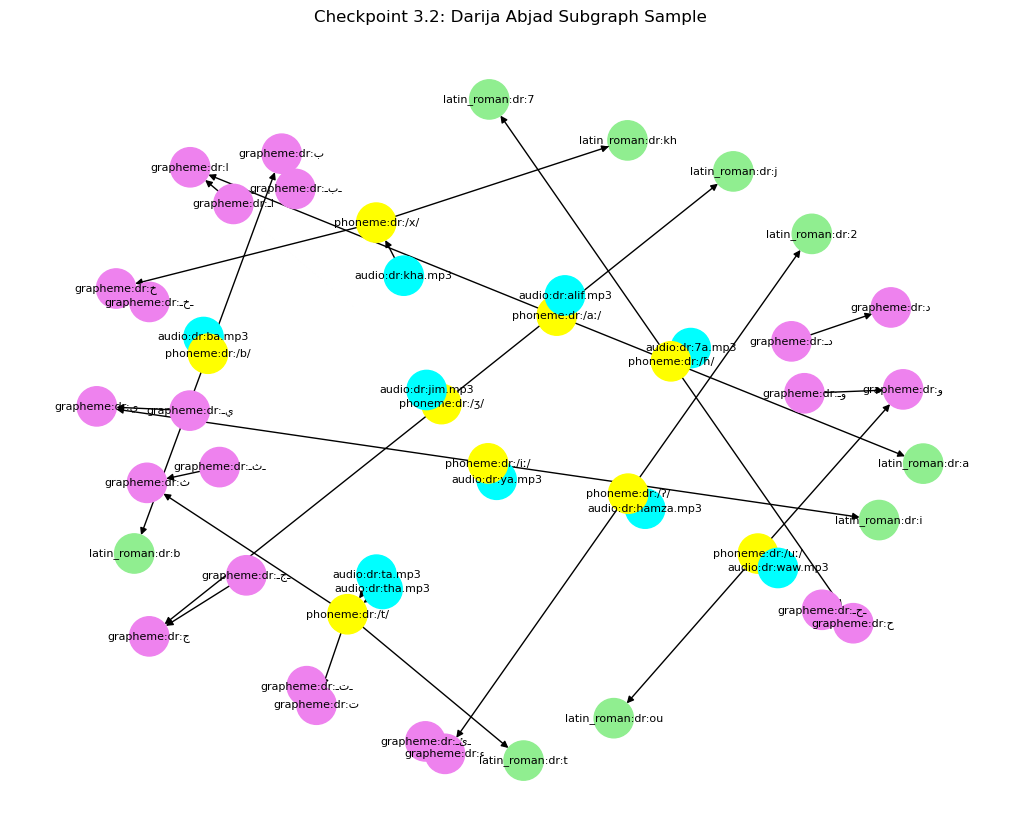

In [63]:
# Visualize Darija abjad layer
import matplotlib.pyplot as plt
import networkx as nx

alphabet_nodes_dr = [n for n in G.nodes() if G.nodes[n].get('type') in ['Grapheme', 'Phoneme', 'Audio', 'Lemma-roman-latin'] and G.nodes[n].get('language') == 'dr']

if alphabet_nodes_dr:
    subG_alphabet_dr = G.subgraph(alphabet_nodes_dr[:50])
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(subG_alphabet_dr, seed=42)
    color_map = []
    
    for node in subG_alphabet_dr.nodes():
        t = subG_alphabet_dr.nodes[node].get('type', '')
        if t == 'Grapheme': 
            color_map.append('violet')
        elif t == 'Phoneme': 
            color_map.append('yellow')
        elif t == 'Audio': 
            color_map.append('cyan')
        elif t == 'Lemma-roman-latin':
            color_map.append('lightgreen')
        else: 
            color_map.append('lightgray')
    
    nx.draw(subG_alphabet_dr, pos, with_labels=True, node_color=color_map, node_size=800, font_size=8)
    plt.title("Checkpoint 3.2: Darija Abjad Subgraph Sample")
    plt.show()
else:
    print("No Darija abjad nodes available to visualize.")


## Export graph artifacts
Export the graphml, nodes.csv, and edges.csv.

In [74]:
nodes_data = []
for node, data in G.nodes(data=True):
    row = {'id': node}
    row.update(data)
    nodes_data.append(row)
pd.DataFrame(nodes_data).to_csv('artifacts/nodes.csv', index=False)

edges_data = []
for u, v, data in G.edges(data=True):
    row = {'source': u, 'target': v}
    row.update(data)
    edges_data.append(row)
pd.DataFrame(edges_data).to_csv('artifacts/edges.csv', index=False)

nx.write_graphml(G, 'artifacts/graph.graphml')
print("Exported graph.graphml, nodes.csv, and edges.csv.")

Exported graph.graphml, nodes.csv, and edges.csv.


## Validate graph
Validate sizes, relations, and flag warnings for incomplete components.

In [65]:
print("=== Validation Summary ===")
print(f"Total Nodes: {G.number_of_nodes()}")
node_types = {}
for n, d in G.nodes(data=True):
    t = d.get('type', 'Unknown')
    node_types[t] = node_types.get(t, 0) + 1
for t, count in node_types.items():
    print(f"  {t}: {count}")

print(f"\nTotal Edges: {G.number_of_edges()}")
edge_relations = {}
for u, v, d in G.edges(data=True):
    r = d.get('relation', 'Unknown')
    edge_relations[r] = edge_relations.get(r, 0) + 1
for r, count in edge_relations.items():
    print(f"  {r}: {count}")

components = list(nx.weakly_connected_components(G))
print(f"\nConnected Components (Weak): {len(components)}")

# Checks
eng_lemmas = [n for n, d in G.nodes(data=True) if d.get('type') == 'Lemma-eng']
lang_lemmas = [n for n, d in G.nodes(data=True) if d.get('type') == 'Lemma-lang']
domains = [n for n, d in G.nodes(data=True) if d.get('type') == 'Domain']

eng_unlinked = sum(1 for n in eng_lemmas if G.out_degree(n) == 0 and G.in_degree(n) == 0)
lang_unlinked = sum(1 for n in lang_lemmas if G.out_degree(n) == 0 and G.in_degree(n) == 0)
domain_unlinked = sum(1 for n in domains if G.in_degree(n) == 0)

if eng_unlinked > 0: print(f"WARNING: {eng_unlinked} Lemma-eng nodes unlinked.")
if lang_unlinked > 0: print(f"WARNING: {lang_unlinked} Lemma-lang nodes unlinked.")
if domain_unlinked > 0: print(f"WARNING: {domain_unlinked} Domain nodes unlinked.")

if not resources['abugida']:
    print("Notice: No abugida resources attached.")
else:
    audio_edges = sum(1 for _, _, d in G.edges(data=True) if d.get('relation') == 'audio_represents')
    if audio_edges == 0:
        print("WARNING: Abugida resource provided, but no 'audio_represents' paths found.")


=== Validation Summary ===
Total Nodes: 290518
  Concept: 108719
  Synset: 108569
  Domain: 45
  Lemma-eng: 22104
  Lemma-lang: 37800
  Lemma-roman: 12414
  Grapheme: 337
  Phoneme: 194
  Lemma-roman-abugida: 48
  Audio: 216
  Lemma-roman-latin: 72

Total Edges: 307013
  mapped_to_synset: 108569
  belongs_to_domain: 108569
  english_label_for: 28152
  target_label_for: 48109
  romanised_as: 12853
  phoneme_written_as: 216
  phoneme_transliterated_as: 206
  audio_represents: 216
  uppercase_of: 89
  variant_of: 34

Connected Components (Weak): 153


## interesting observations:

1. concept: 109719 and synset: 108569 --> some concepts dont seem to have wordnet mappings. exists in ukc but does not have corresponding entries in wordnet 3.0.
2. but all synsets belong to some domain, even if some are not specific enough as categories 
3. 37800 target language nodes 
4. 

## Exploration for validating

In [66]:
def explore_node(G, node_id):
    """
    Shows all connections for a given node.
    """
    if node_id not in G.nodes():
        print(f"Node not found: {node_id}")
        return
    
    print(f"\n=== Node: {node_id} ===")
    print(f"Attributes: {G.nodes[node_id]}")
    
    print(f"\nOutgoing edges:")
    for source, target, data in G.out_edges(node_id, data=True):
        print(f"  {source} --[{data.get('relation')}]--> {target}")
    
    print(f"\nIncoming edges:")
    for source, target, data in G.in_edges(node_id, data=True):
        print(f"  {source} --[{data.get('relation')}]--> {target}")


def find_node(G, search_text):
    """
    Find nodes containing search_text.
    """
    matches = [n for n in G.nodes() if search_text.lower() in n.lower()]
    print(f"\nFound {len(matches)} matches:")
    for m in matches[:20]:
        print(f"  {m}")
    return matches




In [67]:
# Example 1: Explore a concept
explore_node(G, 'concept:2')


=== Node: concept:2 ===
Attributes: {'type': 'Concept', 'concept_id': '2'}

Outgoing edges:
  concept:2 --[mapped_to_synset]--> synset:06333653-n
  concept:2 --[belongs_to_domain]--> domain:noun.communication

Incoming edges:
  lemma:eng:name --[english_label_for]--> concept:2
  lemma:np:नाम --[target_label_for]--> concept:2
  lemma:vn:tên --[target_label_for]--> concept:2
  lemma:ur:اسم --[target_label_for]--> concept:2
  lemma:ur:عرف --[target_label_for]--> concept:2
  lemma:ur:کنیت --[target_label_for]--> concept:2
  lemma:ur:لقب --[target_label_for]--> concept:2
  lemma:ur:نام --[target_label_for]--> concept:2
  lemma:dr:اسم --[target_label_for]--> concept:2
  lemma:dr:اسمية --[target_label_for]--> concept:2


In [68]:
# Example 2: Find and explore an English word
find_node(G, 'dog')


Found 10 matches:
  lemma:eng:dogfight
  lemma:eng:dogtooth
  lemma:eng:underdog
  lemma:eng:endogen
  lemma:eng:dog
  lemma:eng:domestic dog
  lemma:eng:bulldog
  lemma:eng:english bulldog
  lemma:eng:devil dog
  lemma:eng:rain cats and dogs


['lemma:eng:dogfight',
 'lemma:eng:dogtooth',
 'lemma:eng:underdog',
 'lemma:eng:endogen',
 'lemma:eng:dog',
 'lemma:eng:domestic dog',
 'lemma:eng:bulldog',
 'lemma:eng:english bulldog',
 'lemma:eng:devil dog',
 'lemma:eng:rain cats and dogs']

In [69]:
explore_node(G, 'lemma:eng:name')



=== Node: lemma:eng:name ===
Attributes: {'type': 'Lemma-eng', 'language': 'eng', 'text': 'name'}

Outgoing edges:
  lemma:eng:name --[english_label_for]--> concept:2
  lemma:eng:name --[english_label_for]--> concept:35415
  lemma:eng:name --[english_label_for]--> concept:97516
  lemma:eng:name --[english_label_for]--> concept:104475
  lemma:eng:name --[english_label_for]--> concept:95780
  lemma:eng:name --[english_label_for]--> concept:97144
  lemma:eng:name --[english_label_for]--> concept:97507
  lemma:eng:name --[english_label_for]--> concept:97528
  lemma:eng:name --[english_label_for]--> concept:5774
  lemma:eng:name --[english_label_for]--> concept:51203

Incoming edges:


In [70]:
explore_node(G, 'lemma:np:नाम')



=== Node: lemma:np:नाम ===
Attributes: {'type': 'Lemma-lang', 'language': 'np', 'text': 'नाम'}

Outgoing edges:
  lemma:np:नाम --[target_label_for]--> concept:2
  lemma:np:नाम --[romanised_as]--> roman:np:name
  lemma:np:नाम --[target_label_for]--> concept:69074

Incoming edges:


In [71]:
import io, contextlib

# Capture the function output
f = io.StringIO()
with contextlib.redirect_stdout(f):
    explore_node(G, 'domain:noun.animal')

all_lines = f.getvalue().splitlines()

# Print the first 20 lines
print("\n".join(all_lines[:20]))

# Print the total count
print(f"\n--- Total lines generated: {len(all_lines)} ---")


=== Node: domain:noun.animal ===
Attributes: {'type': 'Domain', 'domain': 'noun.animal'}

Outgoing edges:

Incoming edges:
  concept:10000 --[belongs_to_domain]--> domain:noun.animal
  concept:10001 --[belongs_to_domain]--> domain:noun.animal
  concept:10002 --[belongs_to_domain]--> domain:noun.animal
  concept:10003 --[belongs_to_domain]--> domain:noun.animal
  concept:10004 --[belongs_to_domain]--> domain:noun.animal
  concept:10005 --[belongs_to_domain]--> domain:noun.animal
  concept:10006 --[belongs_to_domain]--> domain:noun.animal
  concept:10007 --[belongs_to_domain]--> domain:noun.animal
  concept:10008 --[belongs_to_domain]--> domain:noun.animal
  concept:10009 --[belongs_to_domain]--> domain:noun.animal
  concept:10010 --[belongs_to_domain]--> domain:noun.animal
  concept:10011 --[belongs_to_domain]--> domain:noun.animal
  concept:10012 --[belongs_to_domain]--> domain:noun.animal

--- Total lines generated: 7419 ---


In [72]:
explore_node(G, 'grapheme:vn:â')


=== Node: grapheme:vn:â ===
Attributes: {'type': 'Grapheme', 'language': 'vn', 'char': 'â', 'char_type': 'Vowel'}

Outgoing edges:

Incoming edges:
  grapheme:vn:Â --[uppercase_of]--> grapheme:vn:â
  phoneme:vn:/ə˧/ --[phoneme_written_as]--> grapheme:vn:â


In [73]:
explore_node(G, 'grapheme:np:छ')


=== Node: grapheme:np:छ ===
Attributes: {'type': 'Grapheme', 'language': 'np', 'char': 'छ'}

Outgoing edges:

Incoming edges:
  phoneme:np:/tsʰʌ/ --[phoneme_written_as]--> grapheme:np:छ
